In [1]:

import subprocess
subprocess.run(["pip", "install", "fredapi", "-q"])


import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from fredapi import Fred

print("Ready!")

Ready!


In [2]:

fred = Fred(api_key='5c383e39cd4a8fbe7e214ebf17f156fc')


unemployment = fred.get_series('UNRATE', observation_start='2000-01-01')
wages = fred.get_series('CES0500000003', observation_start='2000-01-01')

print("Unemployment data points:", len(unemployment))
print("Wage data points:", len(wages))
print("\nUnemployment sample:\n", unemployment.tail(5))
print("\nWage sample:\n", wages.tail(5))

Unemployment data points: 313
Wage data points: 239

Unemployment sample:
 2025-09-01    4.4
2025-10-01    NaN
2025-11-01    4.5
2025-12-01    4.4
2026-01-01    4.3
dtype: float64

Wage sample:
 2025-09-01    36.70
2025-10-01    36.85
2025-11-01    37.00
2025-12-01    37.02
2026-01-01    37.17
dtype: float64


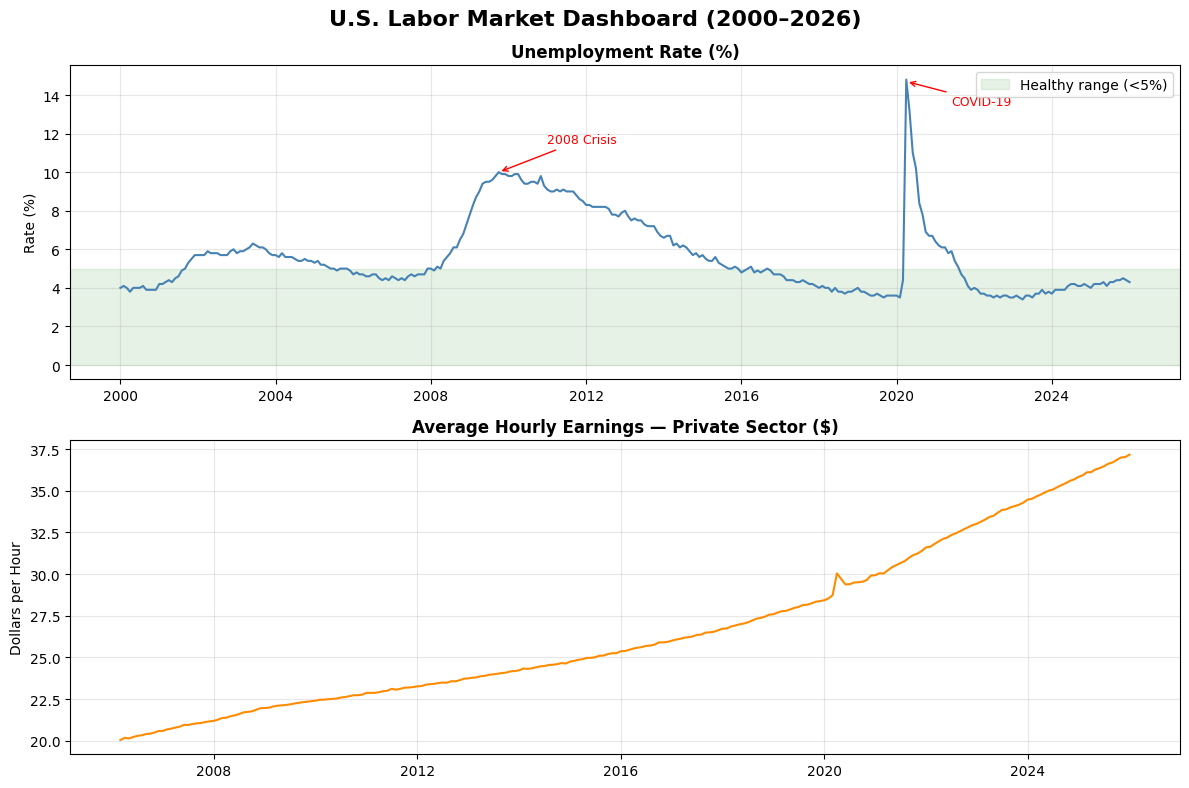

Dashboard saved!


In [4]:

unemployment = unemployment.ffill()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle('U.S. Labor Market Dashboard (2000–2026)', fontsize=16, fontweight='bold')


axes[0].plot(unemployment.index, unemployment.values, color='steelblue', linewidth=1.5)
axes[0].axhspan(0, 5, alpha=0.1, color='green', label='Healthy range (<5%)')
axes[0].set_title('Unemployment Rate (%)', fontweight='bold')
axes[0].set_ylabel('Rate (%)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)


axes[0].annotate('2008 Crisis', xy=(pd.Timestamp('2009-10-01'), 10.0),
    xytext=(pd.Timestamp('2011-01-01'), 11.5),
    arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
axes[0].annotate('COVID-19', xy=(pd.Timestamp('2020-04-01'), 14.7),
    xytext=(pd.Timestamp('2021-06-01'), 13.5),
    arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)


axes[1].plot(wages.index, wages.values, color='darkorange', linewidth=1.5)
axes[1].set_title('Average Hourly Earnings — Private Sector ($)', fontweight='bold')
axes[1].set_ylabel('Dollars per Hour')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('labor_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("Dashboard saved!")

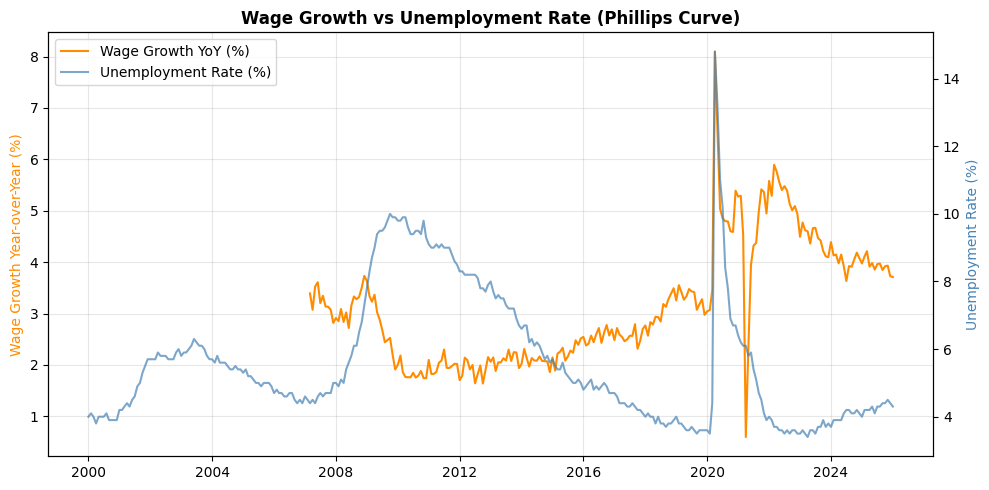

In [5]:

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(wages.index, wages.pct_change(12) * 100, color='darkorange', linewidth=1.5, label='Wage Growth YoY (%)')
ax2 = ax.twinx()
ax2.plot(unemployment.index, unemployment.values, color='steelblue', linewidth=1.5, label='Unemployment Rate (%)', alpha=0.7)

ax.set_ylabel('Wage Growth Year-over-Year (%)', color='darkorange')
ax2.set_ylabel('Unemployment Rate (%)', color='steelblue')
ax.set_title('Wage Growth vs Unemployment Rate (Phillips Curve)', fontweight='bold')
ax.grid(True, alpha=0.3)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('phillips_curve.png', dpi=150, bbox_inches='tight')
plt.show()